# EfficientNet ASPP CBAM Rebalanced

This notebook implements a rebalanced ASPP-CBAM food segmentation experiment. It keeps the validation and test sets unchanged for fair comparison, while changing only the training data pipeline: rare-class-aware sampling, foreground-aware cropping, moderate augmentation, and capped class-balanced loss.

## 1. Libraries

This section imports the required libraries, keeps the PyTorch model cache inside the project folder, and uses plain text progress bars to avoid VS Code widget rendering issues.

In [1]:
from pathlib import Path
import json
import math
import os
import random
import time

TORCH_CACHE_DIR = Path.cwd().resolve() / "Torch_Model_Cache"
TORCH_CACHE_DIR.mkdir(parents=True, exist_ok=True)
os.environ["TORCH_HOME"] = str(TORCH_CACHE_DIR)

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image, ImageEnhance
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision.models import EfficientNet_B0_Weights, efficientnet_b0
from tqdm.std import tqdm

print("PyTorch:", torch.__version__)
print("Torch model cache:", TORCH_CACHE_DIR)
print(
    "Available device:",
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu",
)

PyTorch: 2.11.0+cu128
Torch model cache: /content/Torch_Model_Cache
Available device: cuda


## 2. Constants and Paths

This section defines the fixed project settings. The split is not changed, so results remain comparable with the previous baseline and ASPP-CBAM experiments.

In [2]:
def seed_everything(seed=9444):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True


try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
except Exception:
    pass


CANDIDATE_ROOTS = [
    Path.cwd().resolve(),
    Path("/content/drive/MyDrive/COMP9444/9444"),
    Path("/content/9444"),
]


def find_project_root():
    for root in CANDIDATE_ROOTS:
        data_root = root / "UECFOODPIX" / "data" / "UECFoodPIX"
        split_file = root / "uecfoodpix_split_train3000_val500.json"
        category_file = root / "UECFOODPIX" / "data" / "category.txt"
        if data_root.exists() and split_file.exists() and category_file.exists():
            return root
    checked = "\n".join(str(root) for root in CANDIDATE_ROOTS)
    raise FileNotFoundError("Missing dataset, split JSON, or category file. Checked:\n" + checked)


PROJECT_ROOT = find_project_root()
DATA_ROOT = PROJECT_ROOT / "UECFOODPIX" / "data" / "UECFoodPIX"
SPLIT_FILE = PROJECT_ROOT / "uecfoodpix_split_train3000_val500.json"
CATEGORY_FILE = PROJECT_ROOT / "UECFOODPIX" / "data" / "category.txt"
BEST_MODEL_DIR = PROJECT_ROOT / "Best_Model"
BEST_MODEL_DIR.mkdir(parents=True, exist_ok=True)

NUM_CLASSES = 103
WIDTH = 384
HEIGHT = 320
BATCH_SIZE = 16
MAX_EPOCHS = 45
SEED = 9444
NUM_WORKERS = 0
IGNORE_BACKGROUND_IN_MIOU = True

seed_everything(SEED)

print("Project root:", PROJECT_ROOT)
print("Data root:", DATA_ROOT)
print("Split file:", SPLIT_FILE)
print("Category file:", CATEGORY_FILE)
print("Best model directory:", BEST_MODEL_DIR)
print(f"Input size: {HEIGHT} x {WIDTH}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Max epochs: {MAX_EPOCHS}")

Mounted at /content/drive
Project root: /content/drive/MyDrive/COMP9444/9444
Data root: /content/drive/MyDrive/COMP9444/9444/UECFOODPIX/data/UECFoodPIX
Split file: /content/drive/MyDrive/COMP9444/9444/uecfoodpix_split_train3000_val500.json
Category file: /content/drive/MyDrive/COMP9444/9444/UECFOODPIX/data/category.txt
Best model directory: /content/drive/MyDrive/COMP9444/9444/Best_Model
Input size: 320 x 384
Batch size: 16
Max epochs: 45


## 3. Load Split and Class Names

This section loads the fixed train/validation split from JSON, lists the official test ids, and reads food category names.

In [3]:
def load_split(split_file):
    split_data = json.loads(Path(split_file).read_text(encoding="utf-8"))
    train_ids = [str(item) for item in split_data["train_ids"]]
    val_ids = [str(item) for item in split_data["val_ids"]]
    assert len(train_ids) == split_data["train_size"]
    assert len(val_ids) == split_data["val_size"]
    assert len(train_ids) == len(set(train_ids))
    assert len(val_ids) == len(set(val_ids))
    assert not (set(train_ids) & set(val_ids))
    return train_ids, val_ids, split_data


def list_test_ids(data_root):
    return sorted(path.stem for path in (data_root / "test" / "img").glob("*.jpg"))


def load_class_names(category_file, num_classes=NUM_CLASSES):
    class_names = [f"class_{index}" for index in range(num_classes)]
    class_names[0] = "background"
    with open(category_file, "r", encoding="utf-8") as file:
        for line in file:
            line = line.strip()
            if not line or line.lower().startswith("id"):
                continue
            parts = line.split(maxsplit=1)
            if len(parts) != 2:
                continue
            class_id = int(parts[0])
            if 0 <= class_id < num_classes:
                class_names[class_id] = parts[1]
    return class_names


train_ids, val_ids, split_data = load_split(SPLIT_FILE)
test_ids = list_test_ids(DATA_ROOT)
CLASS_NAMES = load_class_names(CATEGORY_FILE)

print(f"Train images: {len(train_ids)}")
print(f"Validation images: {len(val_ids)}")
print(f"Test images: {len(test_ids)}")
print("First classes:", CLASS_NAMES[:10])

Train images: 3000
Validation images: 500
Test images: 1000
First classes: ['background', 'rice', 'eels on rice', 'pilaf', "chicken-'n'-egg on rice", 'pork cutlet on rice', 'beef curry', 'sushi', 'chicken rice', 'fried rice']


## 4. Rebalanced Data Metadata

This section counts training-set class presence and builds rare-class-aware sample weights. Images containing rare classes become more likely to appear in training batches, while validation and test remain unchanged.

In [4]:
def load_mask_array(data_root, split, image_id):
    mask = Image.open(data_root / split / "mask" / f"{image_id}.png")
    if mask.mode != "L":
        mask = mask.split()[0]
    mask_array = np.asarray(mask, dtype=np.int64)
    return np.where((0 <= mask_array) & (mask_array < NUM_CLASSES), mask_array, 0)


def count_split_classes(data_root, split, image_ids, num_classes=NUM_CLASSES):
    image_counts = np.zeros(num_classes, dtype=np.int64)
    pixel_counts = np.zeros(num_classes, dtype=np.int64)
    image_labels = {}

    for image_id in tqdm(
        image_ids,
        desc=f"Counting {split}",
        bar_format="{desc}: {percentage:3.0f}%|{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}]",
    ):
        mask_array = load_mask_array(data_root, split, image_id)
        labels, counts = np.unique(mask_array, return_counts=True)
        image_counts[labels] += 1
        pixel_counts[labels] += counts
        image_labels[image_id] = labels.tolist()

    return image_counts, pixel_counts, image_labels


train_image_counts, train_pixel_counts, train_image_labels = count_split_classes(DATA_ROOT, "train", train_ids)
val_image_counts, val_pixel_counts, _ = count_split_classes(DATA_ROOT, "train", val_ids)
test_image_counts, test_pixel_counts, _ = count_split_classes(DATA_ROOT, "test", test_ids)

foreground_ids = np.arange(1, NUM_CLASSES)
print("Background pixel percent in train:", train_pixel_counts[0] / max(train_pixel_counts.sum(), 1) * 100)
print("Foreground train image count min/median/mean/max:",
      train_image_counts[foreground_ids].min(),
      np.median(train_image_counts[foreground_ids]),
      round(train_image_counts[foreground_ids].mean(), 2),
      train_image_counts[foreground_ids].max())


def build_sample_weights(image_ids, image_labels, class_image_counts):
    class_counts = np.maximum(class_image_counts.astype(np.float64), 1.0)
    target_count = np.median(class_counts[1:])
    class_sampling_weights = np.sqrt(target_count / class_counts)
    class_sampling_weights = np.clip(class_sampling_weights, 0.35, 2.50)
    class_sampling_weights[0] = 0.0
    class_sampling_weights[101] = min(class_sampling_weights[101], 0.55)
    class_sampling_weights[102] = min(class_sampling_weights[102], 0.70)

    sample_weights = []
    for image_id in image_ids:
        labels = [label for label in image_labels[image_id] if label != 0]
        if labels:
            weight = max(class_sampling_weights[labels])
        else:
            weight = 0.35
        sample_weights.append(float(np.clip(weight, 0.35, 2.50)))
    return torch.tensor(sample_weights, dtype=torch.double), class_sampling_weights


TRAIN_SAMPLE_WEIGHTS, CLASS_SAMPLING_WEIGHTS = build_sample_weights(
    train_ids, train_image_labels, train_image_counts
)

print("Sample weight min/median/mean/max:",
      float(TRAIN_SAMPLE_WEIGHTS.min()),
      float(TRAIN_SAMPLE_WEIGHTS.median()),
      float(TRAIN_SAMPLE_WEIGHTS.mean()),
      float(TRAIN_SAMPLE_WEIGHTS.max()))

rare_order = foreground_ids[np.argsort(train_image_counts[foreground_ids])]
print("\n20 rarest foreground classes in train:")
for class_id in rare_order[:20]:
    print(
        f"{class_id:3d} {CLASS_NAMES[class_id]:30s} "
        f"train_images={int(train_image_counts[class_id]):3d} "
        f"val_images={int(val_image_counts[class_id]):3d} "
        f"test_images={int(test_image_counts[class_id]):3d} "
        f"sample_weight={CLASS_SAMPLING_WEIGHTS[class_id]:.3f}"
    )

Counting test: 100%|██████████| 1000/1000 [03:56<00:00,  4.23it/s]

Background pixel percent in train: 58.46494249281087
Foreground train image count min/median/mean/max: 18 28.0 40.5 673
Sample weight min/median/mean/max: 0.35 0.982607368881035 0.9269958116354563 1.247219128924647

20 rarest foreground classes in train:
 81 steamed meat dumpling          train_images= 18 val_images=  3 test_images=  9 sample_weight=1.247
 14 roll bread                     train_images= 21 val_images=  3 test_images= 12 sample_weight=1.155
 33 grilled eggplant               train_images= 21 val_images=  3 test_images= 12 sample_weight=1.155
 46 grilled salmon                 train_images= 22 val_images=  3 test_images= 15 sample_weight=1.128
 61 beef steak                     train_images= 22 val_images=  4 test_images=  6 sample_weight=1.128
 41 ganmodoki                      train_images= 23 val_images=  3 test_images= 12 sample_weight=1.103
 60 hambarg steak                  train_images= 23 val_images=  6 test_images= 10 sample_weight=1.103
  8 chicken rice        

## 5. Dataset and Foreground-Aware Augmentation

This section changes only the training data pipeline. The training split uses rare-class sampling plus foreground-aware crops. Validation and test are resized and normalised without random augmentation.

In [5]:
RESAMPLE_BILINEAR = Image.Resampling.BILINEAR if hasattr(Image, "Resampling") else Image.BILINEAR
RESAMPLE_NEAREST = Image.Resampling.NEAREST if hasattr(Image, "Resampling") else Image.NEAREST

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

AUGMENTATION_CONFIG = {
    "horizontal_flip_prob": 0.5,
    "foreground_crop_prob": 0.55,
    "crop_scale_min": 0.70,
    "crop_scale_max": 0.95,
    "random_crop_scale_min": 0.90,
    "random_crop_scale_max": 1.0,
    "aspect_min": 0.90,
    "aspect_max": 1.10,
    "rotation_degrees": 8,
    "brightness": 0.12,
    "contrast": 0.12,
    "saturation": 0.10,
}


def resize_pair(image, mask, width=WIDTH, height=HEIGHT):
    image = image.resize((width, height), RESAMPLE_BILINEAR)
    mask = mask.resize((width, height), RESAMPLE_NEAREST)
    return image, mask


def random_crop_box(img_w, img_h, scale_min, scale_max, aspect_min, aspect_max):
    area = img_w * img_h
    for _ in range(10):
        target_area = area * random.uniform(scale_min, scale_max)
        aspect = random.uniform(aspect_min, aspect_max)
        crop_w = int(round(math.sqrt(target_area * aspect)))
        crop_h = int(round(math.sqrt(target_area / aspect)))
        if 0 < crop_w <= img_w and 0 < crop_h <= img_h:
            left = random.randint(0, img_w - crop_w)
            top = random.randint(0, img_h - crop_h)
            return left, top, left + crop_w, top + crop_h
    return 0, 0, img_w, img_h


def foreground_crop_box(mask_array, config):
    img_h, img_w = mask_array.shape
    foreground_labels = np.unique(mask_array[mask_array > 0])
    if len(foreground_labels) == 0:
        return random_crop_box(
            img_w, img_h,
            config["random_crop_scale_min"], config["random_crop_scale_max"],
            config["aspect_min"], config["aspect_max"],
        )

    label_weights = CLASS_SAMPLING_WEIGHTS[foreground_labels]
    label_weights = label_weights / max(label_weights.sum(), 1e-8)
    selected_label = int(np.random.choice(foreground_labels, p=label_weights))
    ys, xs = np.where(mask_array == selected_label)
    point_index = random.randrange(len(xs))
    center_x = int(xs[point_index])
    center_y = int(ys[point_index])

    area = img_w * img_h
    target_area = area * random.uniform(config["crop_scale_min"], config["crop_scale_max"])
    aspect = random.uniform(config["aspect_min"], config["aspect_max"])
    crop_w = min(img_w, max(16, int(round(math.sqrt(target_area * aspect)))))
    crop_h = min(img_h, max(16, int(round(math.sqrt(target_area / aspect)))))

    left_min = max(0, center_x - crop_w + 1)
    left_max = min(center_x, img_w - crop_w)
    top_min = max(0, center_y - crop_h + 1)
    top_max = min(center_y, img_h - crop_h)
    left = random.randint(left_min, left_max) if left_min <= left_max else max(0, min(center_x - crop_w // 2, img_w - crop_w))
    top = random.randint(top_min, top_max) if top_min <= top_max else max(0, min(center_y - crop_h // 2, img_h - crop_h))
    return left, top, left + crop_w, top + crop_h


def apply_train_augmentation(image, mask, config):
    mask_array = np.asarray(mask, dtype=np.int64)
    if random.random() < config["foreground_crop_prob"]:
        crop_box = foreground_crop_box(mask_array, config)
    else:
        img_w, img_h = image.size
        crop_box = random_crop_box(
            img_w, img_h,
            config["random_crop_scale_min"], config["random_crop_scale_max"],
            config["aspect_min"], config["aspect_max"],
        )
    image = image.crop(crop_box)
    mask = mask.crop(crop_box)
    image, mask = resize_pair(image, mask)

    if random.random() < config["horizontal_flip_prob"]:
        image = image.transpose(Image.Transpose.FLIP_LEFT_RIGHT)
        mask = mask.transpose(Image.Transpose.FLIP_LEFT_RIGHT)

    degrees = config["rotation_degrees"]
    if degrees > 0:
        angle = random.uniform(-degrees, degrees)
        image = image.rotate(angle, resample=RESAMPLE_BILINEAR)
        mask = mask.rotate(angle, resample=RESAMPLE_NEAREST)

    if config["brightness"] > 0:
        image = ImageEnhance.Brightness(image).enhance(random.uniform(1 - config["brightness"], 1 + config["brightness"]))
    if config["contrast"] > 0:
        image = ImageEnhance.Contrast(image).enhance(random.uniform(1 - config["contrast"], 1 + config["contrast"]))
    if config["saturation"] > 0:
        image = ImageEnhance.Color(image).enhance(random.uniform(1 - config["saturation"], 1 + config["saturation"]))

    return image, mask


class FoodSegmentationDataset(Dataset):
    def __init__(self, data_root, image_ids, split, augment=False, augmentation_config=None):
        self.data_root = Path(data_root)
        self.image_ids = [str(item) for item in image_ids]
        self.split = split
        self.augment = augment
        self.augmentation_config = augmentation_config or AUGMENTATION_CONFIG

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, index):
        image_id = self.image_ids[index]
        image = Image.open(self.data_root / self.split / "img" / f"{image_id}.jpg").convert("RGB")
        mask = Image.open(self.data_root / self.split / "mask" / f"{image_id}.png")
        if mask.mode != "L":
            mask = mask.split()[0]

        if self.augment:
            image, mask = apply_train_augmentation(image, mask, self.augmentation_config)
        else:
            image, mask = resize_pair(image, mask)

        image_array = np.asarray(image, dtype=np.float32) / 255.0
        image_tensor = torch.from_numpy(image_array.transpose(2, 0, 1))
        image_tensor = (image_tensor - IMAGENET_MEAN) / IMAGENET_STD

        mask_array = np.asarray(mask, dtype=np.int64)
        mask_array = np.where((0 <= mask_array) & (mask_array < NUM_CLASSES), mask_array, 0)
        mask_tensor = torch.from_numpy(mask_array).long()
        return image_tensor, mask_tensor


train_dataset = FoodSegmentationDataset(DATA_ROOT, train_ids, "train", augment=True)
val_dataset = FoodSegmentationDataset(DATA_ROOT, val_ids, "train", augment=False)
test_dataset = FoodSegmentationDataset(DATA_ROOT, test_ids, "test", augment=False)

print("Datasets ready.")
print("Augmentation config:", AUGMENTATION_CONFIG)

Datasets ready.
Augmentation config: {'horizontal_flip_prob': 0.5, 'foreground_crop_prob': 0.55, 'crop_scale_min': 0.7, 'crop_scale_max': 0.95, 'random_crop_scale_min': 0.9, 'random_crop_scale_max': 1.0, 'aspect_min': 0.9, 'aspect_max': 1.1, 'rotation_degrees': 8, 'brightness': 0.12, 'contrast': 0.12, 'saturation': 0.1}


## 6. Metrics, Sampler, Class Weights, and Plots

This section defines the rebalanced train sampler, capped class weights, segmentation metrics, and U-Net-style blue-white confusion matrix plots.

In [6]:
def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def make_train_loader(dataset):
    generator = torch.Generator()
    generator.manual_seed(SEED)
    sampler = WeightedRandomSampler(
        weights=TRAIN_SAMPLE_WEIGHTS,
        num_samples=len(dataset),
        replacement=True,
        generator=generator,
    )
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        sampler=sampler,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )


def make_eval_loader(dataset):
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )


def build_loss_class_weights(pixel_counts):
    counts = np.maximum(pixel_counts.astype(np.float64), 1.0)
    freq = counts / counts.sum()
    weights = 1.0 / np.sqrt(freq)
    weights = weights / weights[1:].mean()
    weights = np.clip(weights, 0.25, 2.50)
    weights[0] = min(weights[0], 0.25)
    weights[101] = min(weights[101], 1.20)
    weights[102] = min(weights[102], 1.20)
    return torch.tensor(weights, dtype=torch.float32)


LOSS_CLASS_WEIGHTS = build_loss_class_weights(train_pixel_counts)
print("Loss class weights min/median/mean/max:",
      float(LOSS_CLASS_WEIGHTS.min()),
      float(LOSS_CLASS_WEIGHTS.median()),
      float(LOSS_CLASS_WEIGHTS.mean()),
      float(LOSS_CLASS_WEIGHTS.max()))
print("Background loss weight:", float(LOSS_CLASS_WEIGHTS[0]))


def compute_confusion_matrix(preds, targets, num_classes=NUM_CLASSES):
    preds = preds.detach().view(-1).to(torch.int64).cpu()
    targets = targets.detach().view(-1).to(torch.int64).cpu()
    valid = (targets >= 0) & (targets < num_classes)
    encoded = targets[valid] * num_classes + preds[valid].clamp(0, num_classes - 1)
    matrix = torch.bincount(encoded, minlength=num_classes * num_classes)
    return matrix.reshape(num_classes, num_classes).numpy()


def metrics_from_confusion(confusion, ignore_background=IGNORE_BACKGROUND_IN_MIOU):
    confusion = confusion.astype(np.float64)
    true_positive = np.diag(confusion)
    support = confusion.sum(axis=1)
    predicted = confusion.sum(axis=0)
    union = support + predicted - true_positive
    accuracy = true_positive.sum() / max(confusion.sum(), 1.0)
    iou = np.divide(true_positive, union, out=np.full_like(true_positive, np.nan), where=union > 0)
    start = 1 if ignore_background else 0
    valid_iou = iou[start:][~np.isnan(iou[start:])]
    miou = float(valid_iou.mean()) if len(valid_iou) else 0.0
    return {"accuracy": float(accuracy), "miou": miou, "iou_per_class": iou, "support": support}


def plot_training_history(history, model_name):
    epochs = [item["epoch"] for item in history]
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    axes[0].plot(epochs, [item["train_loss"] for item in history], label="Train loss")
    axes[0].plot(epochs, [item["val_loss"] for item in history], label="Validation loss")
    axes[0].set_title(f"{model_name}: Training and Validation Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()
    axes[1].plot(epochs, [item["train_accuracy"] for item in history], label="Train pixel accuracy")
    axes[1].plot(epochs, [item["val_accuracy"] for item in history], label="Validation pixel accuracy")
    axes[1].plot(epochs, [item["train_miou"] for item in history], label="Train mIoU")
    axes[1].plot(epochs, [item["val_miou"] for item in history], label="Validation mIoU")
    axes[1].set_title(f"{model_name}: Accuracy and mIoU")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Score")
    axes[1].set_ylim(0, 1)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    plt.tight_layout()
    plt.show()


def normalized_confusion(confusion):
    matrix = np.asarray(confusion, dtype=np.float64)
    return matrix / np.maximum(matrix.sum(axis=1, keepdims=True), 1)


def plot_overall_confusion(confusion, title):
    normalized = normalized_confusion(confusion)
    fig, ax = plt.subplots(figsize=(9, 8))
    image = ax.imshow(normalized, cmap="Blues", vmin=0, vmax=1, interpolation="nearest")
    ax.set_title(title)
    ax.set_xlabel("Predicted class id")
    ax.set_ylabel("True class id")
    ticks = np.arange(0, NUM_CLASSES, 10)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    plt.show()


def plot_class_subset_heatmap(confusion, class_indices, title):
    normalized = normalized_confusion(confusion)
    subset = normalized[np.ix_(class_indices, class_indices)]
    labels = [CLASS_NAMES[index] for index in class_indices]
    fig, ax = plt.subplots(figsize=(10, 8))
    image = ax.imshow(subset, cmap="Blues", vmin=0, vmax=1, interpolation="nearest")
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks(np.arange(len(labels)), labels=labels, rotation=70, ha="right", fontsize=8)
    ax.set_yticks(np.arange(len(labels)), labels=labels, fontsize=8)
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    plt.show()


def best_worst_class_indices(confusion, top_k=10):
    stats = metrics_from_confusion(confusion)
    per_class_iou = stats["iou_per_class"]
    support = stats["support"]
    valid = support > 0
    valid[0] = False
    valid_indices = np.where(valid)[0]
    ordered = valid_indices[np.argsort(per_class_iou[valid_indices])]
    worst = ordered[:top_k].tolist()
    best = ordered[-top_k:][::-1].tolist()
    return best, worst, stats


def print_class_iou_table(title, indices, per_class_iou, support):
    print(title)
    for index in indices:
        print(f"{index:3d} {CLASS_NAMES[index]:30s} IoU={float(per_class_iou[index]):.4f} support={int(support[index])}")


def plot_best_worst_heatmaps(confusion, model_name):
    best, worst, stats = best_worst_class_indices(confusion, top_k=10)
    print_class_iou_table("Best 10 classes by test IoU", best, stats["iou_per_class"], stats["support"])
    print_class_iou_table("Worst 10 classes by test IoU", worst, stats["iou_per_class"], stats["support"])
    plot_class_subset_heatmap(confusion, best, f"{model_name}: Best 10 classes test heatmap")
    plot_class_subset_heatmap(confusion, worst, f"{model_name}: Worst 10 classes test heatmap")

Loss class weights min/median/mean/max: 0.25 0.9695733785629272 0.9927184581756592 1.7247059345245361
Background loss weight: 0.25


## 7. Model: EfficientNet-B0 + ASPP + CBAM + Upsampling Head

This section keeps the paper-inspired ASPP-CBAM architecture, while the main change in this notebook is the rebalanced data pipeline.

In [7]:
class ConvBNReLU(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, padding=1, dilation=1, dropout=0.0):
        super().__init__()
        layers = [
            nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, padding=padding, dilation=dilation, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        ]
        if dropout > 0:
            layers.append(nn.Dropout2d(dropout))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class ASPP(nn.Module):
    def __init__(self, in_channels, out_channels=256, rates=(1, 2, 4, 6), dropout=0.1):
        super().__init__()
        self.branches = nn.ModuleList([ConvBNReLU(in_channels, out_channels, kernel_size=1, padding=0)])
        for rate in rates:
            self.branches.append(ConvBNReLU(in_channels, out_channels, kernel_size=3, padding=rate, dilation=rate))
        self.global_pool = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            ConvBNReLU(in_channels, out_channels, kernel_size=1, padding=0),
        )
        self.project = ConvBNReLU(out_channels * (len(self.branches) + 1), out_channels, kernel_size=1, padding=0, dropout=dropout)

    def forward(self, x):
        size = x.shape[-2:]
        features = [branch(x) for branch in self.branches]
        pooled = self.global_pool(x)
        pooled = F.interpolate(pooled, size=size, mode="bilinear", align_corners=False)
        features.append(pooled)
        return self.project(torch.cat(features, dim=1))


class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.mlp = nn.Sequential(
            nn.Conv2d(channels, hidden, kernel_size=1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden, channels, kernel_size=1, bias=False),
        )

    def forward(self, x):
        avg = self.mlp(F.adaptive_avg_pool2d(x, 1))
        max_pool = self.mlp(F.adaptive_max_pool2d(x, 1))
        return x * torch.sigmoid(avg + max_pool)


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=kernel_size // 2, bias=False)

    def forward(self, x):
        avg = torch.mean(x, dim=1, keepdim=True)
        max_pool, _ = torch.max(x, dim=1, keepdim=True)
        attention = torch.sigmoid(self.conv(torch.cat([avg, max_pool], dim=1)))
        return x * attention


class CBAM(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.channel_attention = ChannelAttention(channels, reduction=reduction)
        self.spatial_attention = SpatialAttention()

    def forward(self, x):
        x = self.channel_attention(x)
        return self.spatial_attention(x)


class EfficientNetASPPCBAM(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, pretrained=True, dropout=0.18):
        super().__init__()
        weights = EfficientNet_B0_Weights.DEFAULT if pretrained else None
        self.encoder = efficientnet_b0(weights=weights).features
        self.low_feature_index = 2
        self.aspp = ASPP(1280, 256, rates=(1, 2, 4, 6), dropout=dropout)
        self.cbam = CBAM(256, reduction=16)
        self.low_project = ConvBNReLU(24, 48, kernel_size=1, padding=0)
        self.head = nn.Sequential(
            ConvBNReLU(256 + 48, 192, dropout=dropout),
            ConvBNReLU(192, 128, dropout=dropout * 0.5),
            nn.Conv2d(128, num_classes, kernel_size=1),
        )

    def forward(self, x):
        input_size = x.shape[-2:]
        low_feature = None
        for index, layer in enumerate(self.encoder):
            x = layer(x)
            if index == self.low_feature_index:
                low_feature = x
        high_feature = self.cbam(self.aspp(x))
        low_feature = self.low_project(low_feature)
        high_feature = F.interpolate(high_feature, size=low_feature.shape[-2:], mode="bilinear", align_corners=False)
        logits = self.head(torch.cat([high_feature, low_feature], dim=1))
        return F.interpolate(logits, size=input_size, mode="bilinear", align_corners=False)


model_preview = EfficientNetASPPCBAM(pretrained=False)
print(f"EfficientNet-ASPP-CBAM rebalanced parameters: {sum(p.numel() for p in model_preview.parameters()):,}")
del model_preview

EfficientNet-ASPP-CBAM rebalanced parameters: 17,626,149


## 8. Loss and Training Helpers

This section uses capped class-balanced cross-entropy plus Dice loss. Encoder and segmentation modules keep separate learning rates.

In [8]:
class BalancedDiceCrossEntropyLoss(nn.Module):
    def __init__(self, class_weights=None, dice_weight=0.7, ignore_background_in_dice=True, label_smoothing=0.05, smooth=1.0):
        super().__init__()
        if class_weights is None:
            self.class_weights = None
        else:
            self.register_buffer("class_weights", class_weights)
        self.dice_weight = dice_weight
        self.ignore_background_in_dice = ignore_background_in_dice
        self.label_smoothing = label_smoothing
        self.smooth = smooth

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, weight=self.class_weights, label_smoothing=self.label_smoothing)
        probabilities = torch.softmax(logits, dim=1)
        one_hot = F.one_hot(targets, num_classes=logits.shape[1]).permute(0, 3, 1, 2).float()
        start = 1 if self.ignore_background_in_dice else 0
        probabilities = probabilities[:, start:]
        one_hot = one_hot[:, start:]
        dims = (0, 2, 3)
        intersection = torch.sum(probabilities * one_hot, dims)
        cardinality = torch.sum(probabilities + one_hot, dims)
        dice = (2.0 * intersection + self.smooth) / (cardinality + self.smooth)
        return ce_loss + self.dice_weight * (1.0 - dice.mean())


def run_one_epoch(model, loader, criterion, device, optimizer=None, scaler=None):
    training = optimizer is not None
    model.train(training)
    total_loss = 0.0
    total_images = 0
    confusion = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)
    progress = tqdm(
        loader,
        desc="train" if training else "eval",
        bar_format="{desc}: {percentage:3.0f}%|{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}]",
    )
    for images, masks in progress:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)
        if training:
            optimizer.zero_grad(set_to_none=True)
        amp_enabled = device.type == "cuda"
        with torch.set_grad_enabled(training):
            with torch.autocast(device_type="cuda", enabled=amp_enabled):
                logits = model(images)
                loss = criterion(logits, masks)
            if training:
                if scaler is not None and amp_enabled:
                    scaler.scale(loss).backward()
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    optimizer.step()
        batch_size = images.size(0)
        total_loss += loss.item() * batch_size
        total_images += batch_size
        confusion += compute_confusion_matrix(logits.argmax(dim=1), masks)
        progress.set_postfix(loss=f"{total_loss / max(total_images, 1):.4f}")
    metrics = metrics_from_confusion(confusion)
    metrics["loss"] = total_loss / max(total_images, 1)
    metrics["confusion"] = confusion
    return metrics


def set_encoder_trainable(model, trainable):
    for parameter in model.encoder.parameters():
        parameter.requires_grad = trainable


REBALANCED_CONFIG = {
    "encoder_learning_rate": 1e-5,
    "head_learning_rate": 2.5e-4,
    "weight_decay": 5e-4,
    "dropout": 0.20,
    "dice_weight": 0.7,
    "label_smoothing": 0.05,
    "ignore_background_in_dice": True,
    "freeze_encoder_epochs": 5,
    "early_stopping_patience": 8,
    "scheduler_patience": 3,
    "lr_factor": 0.5,
    "pretrained": True,
}

print("Training config:", REBALANCED_CONFIG)

Training config: {'encoder_learning_rate': 1e-05, 'head_learning_rate': 0.00025, 'weight_decay': 0.0005, 'dropout': 0.2, 'dice_weight': 0.7, 'label_smoothing': 0.05, 'ignore_background_in_dice': True, 'freeze_encoder_epochs': 5, 'early_stopping_patience': 8, 'scheduler_patience': 3, 'lr_factor': 0.5, 'pretrained': True}


## 9. Train and Test the Rebalanced Model

This section trains the rebalanced model, saves the best checkpoint by validation mIoU, then reloads that checkpoint and evaluates the test set once.

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /content/Torch_Model_Cache/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 138MB/s] 
/tmp/ipykernel_997/858152261.py:43: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=device.type == "cuda")


Training EfficientNet-ASPP-CBAM Rebalanced on cuda
Best checkpoint target: /content/drive/MyDrive/COMP9444/9444/Best_Model/EfficientNet_ASPP_CBAM_Rebalanced_best_model.pt

Epoch 1/45 | encoder frozen


eval: 100%|██████████| 32/32 [03:13<00:00,  6.04s/it]


{'epoch': 1, 'train_loss': 4.647385941823323, 'val_loss': 4.090933109283447, 'train_accuracy': 0.4890519992404514, 'val_accuracy': 0.6007140787760417, 'train_miou': 0.032179298046177834, 'val_miou': 0.07229248139181693}
Saved new best model: val_mIoU=0.0723

Epoch 2/45 | encoder frozen


...

{'epoch': 43, 'train_loss': 1.5346541887919107, 'val_loss': 2.5102611064910887, 'train_accuracy': 0.9265903347439236, 'val_accuracy': 0.773743212890625, 'train_miou': 0.8492477230506151, 'val_miou': 0.4394277530481408}

Epoch 44/45 | encoder trainable


eval: 100%|██████████| 32/32 [00:08<00:00,  3.97it/s]


{'epoch': 44, 'train_loss': 1.5229273872375488, 'val_loss': 2.5097300148010255, 'train_accuracy': 0.9297730712890625, 'val_accuracy': 0.7693381022135417, 'train_miou': 0.8587702522517622, 'val_miou': 0.43912251922107964}

Epoch 45/45 | encoder trainable


eval: 100%|██████████| 32/32 [00:08<00:00,  3.97it/s]


{'epoch': 45, 'train_loss': 1.5265078620910644, 'val_loss': 2.4973026161193848, 'train_accuracy': 0.9285214029947917, 'val_accuracy': 0.774958251953125, 'train_miou': 0.8529978994482775, 'val_miou': 0.4443248097639378}
Saved new best model: val_mIoU=0.4443
Training finished in 92.4 minutes. Best epoch: 45, best val mIoU: 0.4443


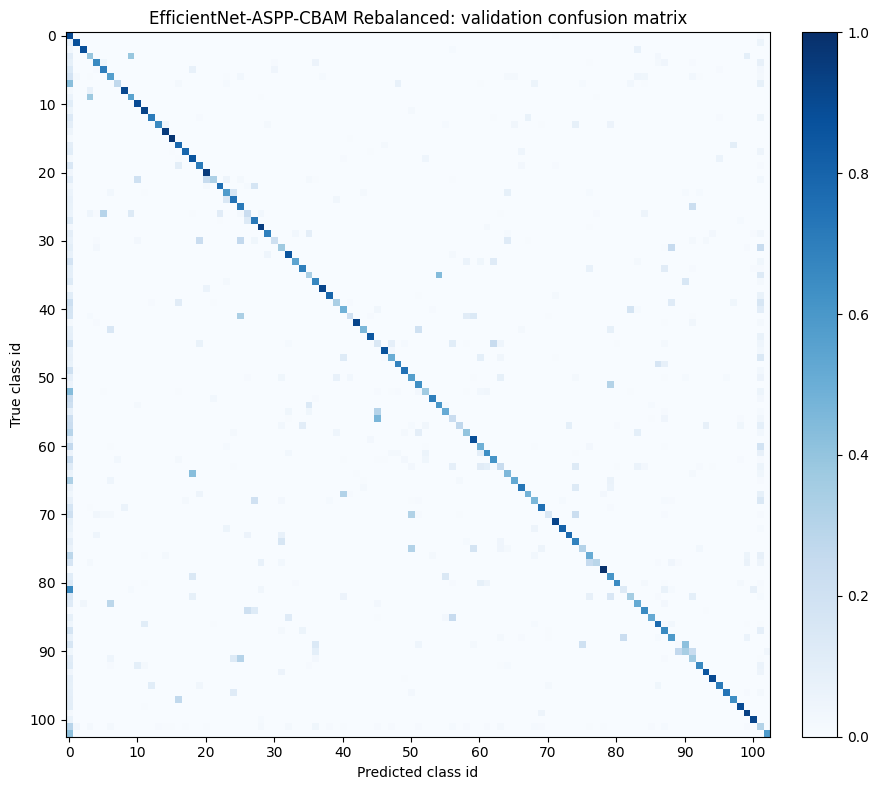

eval: 100%|██████████| 63/63 [05:13<00:00,  4.98s/it]


{'test_loss': 2.585011920928955, 'test_accuracy': 0.7775774332682291, 'test_miou': 0.4329452675344197}


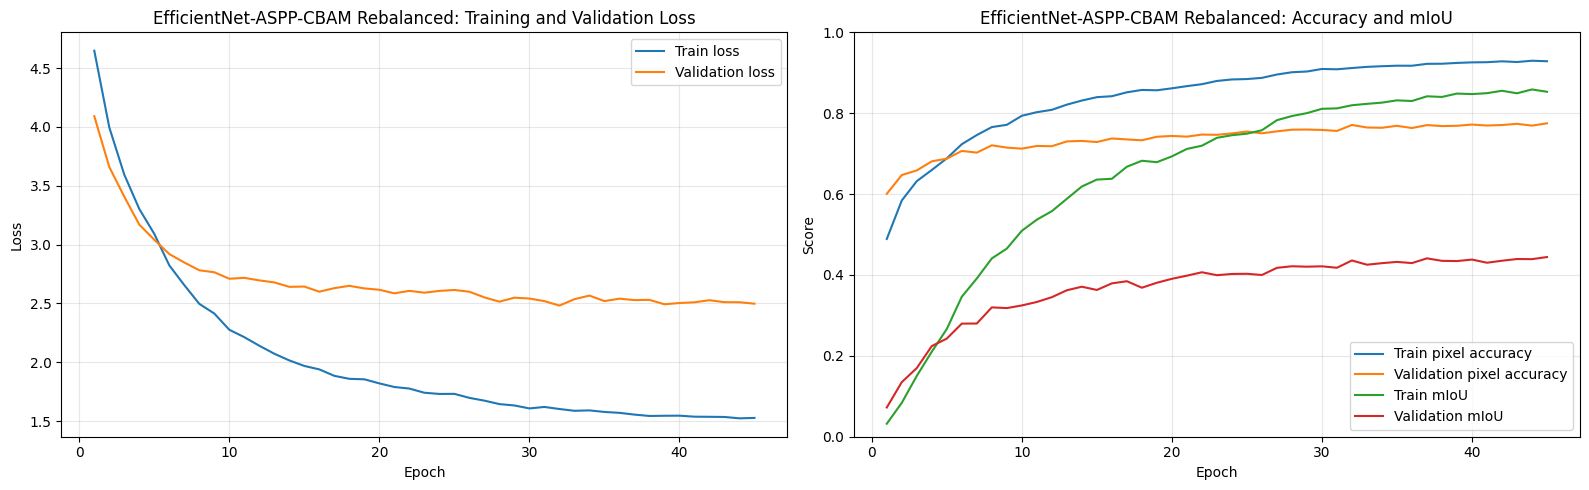

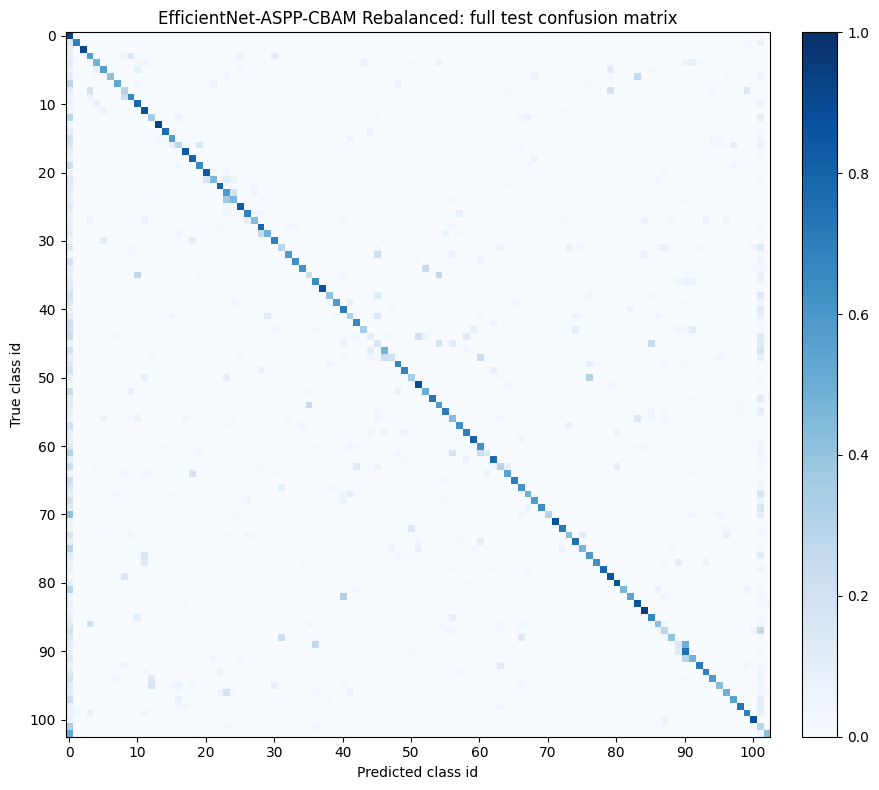

Best 10 classes by test IoU
 13 croissant                      IoU=0.8192 support=635498
  2 eels on rice                   IoU=0.8155 support=458314
 71 egg roll                       IoU=0.7685 support=327967
 84 spaghetti meat sauce           IoU=0.7332 support=426035
 37 potage                         IoU=0.7126 support=470193
 78 fish-shaped pancake with bean jam IoU=0.6979 support=366508
 79 shrimp with chill source       IoU=0.6968 support=707674
 20 udon noodle                    IoU=0.6873 support=713089
 17 hamburger                      IoU=0.6819 support=1081756
 51 sweet and sour pork            IoU=0.6763 support=459207
Worst 10 classes by test IoU
 45 fried fish                     IoU=0.0546 support=255284
 44 teriyaki grilled fish          IoU=0.0553 support=171224
 89 Japanese tofu and vegetable chowder IoU=0.0973 support=343075
 61 beef steak                     IoU=0.1210 support=266150
 47 salmon meuniere                IoU=0.1389 support=143770
  8 chicken rice   

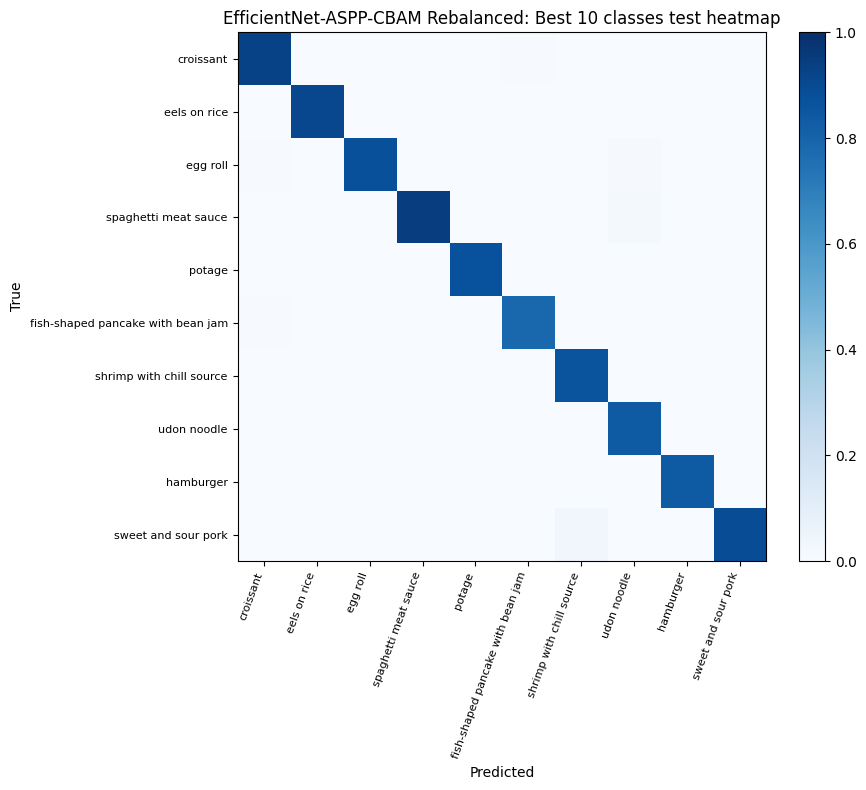

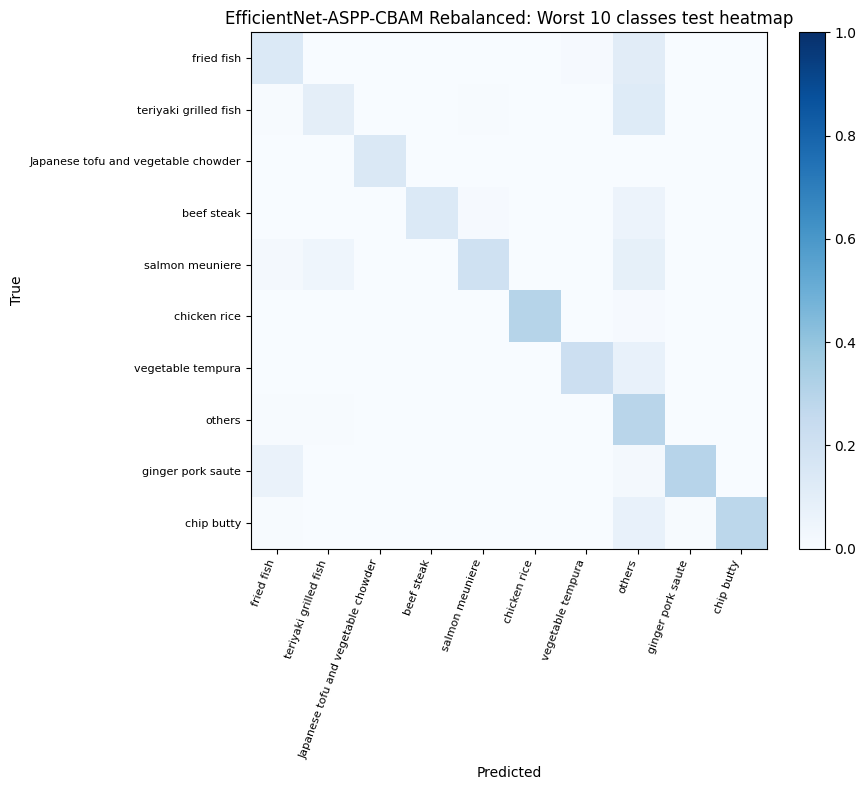

In [9]:
def safe_torch_load(path, device):
    try:
        return torch.load(path, map_location=device, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=device)


def train_rebalanced_aspp_cbam(config):
    seed_everything(SEED)
    train_loader = make_train_loader(train_dataset)
    val_loader = make_eval_loader(val_dataset)
    test_loader = make_eval_loader(test_dataset)
    device = get_device()

    class_weights = LOSS_CLASS_WEIGHTS.to(device)
    model = EfficientNetASPPCBAM(pretrained=config["pretrained"], dropout=config["dropout"]).to(device)
    criterion = BalancedDiceCrossEntropyLoss(
        class_weights=class_weights,
        dice_weight=config["dice_weight"],
        ignore_background_in_dice=config["ignore_background_in_dice"],
        label_smoothing=config["label_smoothing"],
    ).to(device)

    head_parameters = [
        *model.aspp.parameters(),
        *model.cbam.parameters(),
        *model.low_project.parameters(),
        *model.head.parameters(),
    ]
    optimizer = torch.optim.AdamW(
        [
            {"params": model.encoder.parameters(), "lr": config["encoder_learning_rate"]},
            {"params": head_parameters, "lr": config["head_learning_rate"]},
        ],
        weight_decay=config["weight_decay"],
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=config["lr_factor"],
        patience=config["scheduler_patience"],
    )
    scaler = torch.cuda.amp.GradScaler(enabled=device.type == "cuda")
    checkpoint_path = BEST_MODEL_DIR / "EfficientNet_ASPP_CBAM_Rebalanced_best_model.pt"
    history = []
    best_miou = -1.0
    best_epoch = 0
    best_val_confusion = None
    epochs_without_improvement = 0
    start_time = time.time()

    print(f"Training EfficientNet-ASPP-CBAM Rebalanced on {device}")
    print("Best checkpoint target:", checkpoint_path)

    for epoch in range(1, MAX_EPOCHS + 1):
        freeze_encoder = epoch <= config["freeze_encoder_epochs"]
        set_encoder_trainable(model, not freeze_encoder)
        print(f"\nEpoch {epoch}/{MAX_EPOCHS} | encoder {'frozen' if freeze_encoder else 'trainable'}")
        train_metrics = run_one_epoch(model, train_loader, criterion, device, optimizer=optimizer, scaler=scaler)
        with torch.no_grad():
            val_metrics = run_one_epoch(model, val_loader, criterion, device)
        scheduler.step(val_metrics["miou"])
        row = {
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "val_loss": val_metrics["loss"],
            "train_accuracy": train_metrics["accuracy"],
            "val_accuracy": val_metrics["accuracy"],
            "train_miou": train_metrics["miou"],
            "val_miou": val_metrics["miou"],
        }
        history.append(row)
        print(row)
        if val_metrics["miou"] > best_miou:
            best_miou = val_metrics["miou"]
            best_epoch = epoch
            best_val_confusion = val_metrics["confusion"].copy()
            epochs_without_improvement = 0
            torch.save(
                {
                    "model_name": "EfficientNet-ASPP-CBAM-Rebalanced",
                    "model_state_dict": model.state_dict(),
                    "config": config,
                    "batch_size": BATCH_SIZE,
                    "max_epochs": MAX_EPOCHS,
                    "input_size": (HEIGHT, WIDTH),
                    "num_classes": NUM_CLASSES,
                    "best_epoch": best_epoch,
                    "best_val_miou": best_miou,
                    "history": history,
                    "augmentation_config": AUGMENTATION_CONFIG,
                    "class_names": CLASS_NAMES,
                    "sampling_strategy": "WeightedRandomSampler + foreground-aware crop + capped class weights",
                },
                checkpoint_path,
            )
            print(f"Saved new best model: val_mIoU={best_miou:.4f}")
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= config["early_stopping_patience"]:
                print(f"Early stopping after {config['early_stopping_patience']} epochs without validation mIoU improvement")
                break

    elapsed_minutes = (time.time() - start_time) / 60
    print(f"Training finished in {elapsed_minutes:.1f} minutes. Best epoch: {best_epoch}, best val mIoU: {best_miou:.4f}")
    if best_val_confusion is not None:
        plot_overall_confusion(best_val_confusion, "EfficientNet-ASPP-CBAM Rebalanced: validation confusion matrix")

    checkpoint = safe_torch_load(checkpoint_path, device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    with torch.no_grad():
        test_metrics = run_one_epoch(model, test_loader, criterion, device)

    print({"test_loss": test_metrics["loss"], "test_accuracy": test_metrics["accuracy"], "test_miou": test_metrics["miou"]})
    plot_training_history(history, "EfficientNet-ASPP-CBAM Rebalanced")
    plot_overall_confusion(test_metrics["confusion"], "EfficientNet-ASPP-CBAM Rebalanced: full test confusion matrix")
    plot_best_worst_heatmaps(test_metrics["confusion"], "EfficientNet-ASPP-CBAM Rebalanced")
    return {
        "model": model,
        "history": history,
        "best_epoch": best_epoch,
        "best_val_miou": best_miou,
        "test_metrics": test_metrics,
        "checkpoint_path": checkpoint_path,
    }


rebalanced_aspp_cbam_result = train_rebalanced_aspp_cbam(REBALANCED_CONFIG)

## 10. Result Interpretation

！！！请在此处解释分析结果！！！

Suggested points to discuss after training:

- Whether rare-class-aware sampling improves the worst 10 foreground classes.
- Whether foreground-aware crop reduces the dominance of background pixels.
- Whether validation mIoU improves compared with EfficientNet-ASPP-CBAM without rebalancing.
- Whether the train-validation gap becomes smaller or overfitting remains.
- Whether the final result is competitive with the simpler EfficientNet data augmentation model.